In [ ]:
pip install rasterio matplotlib numpy

0 -> Non-Water(land, vegetation, etc.)

1 -> Water

2 -> Sediment

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


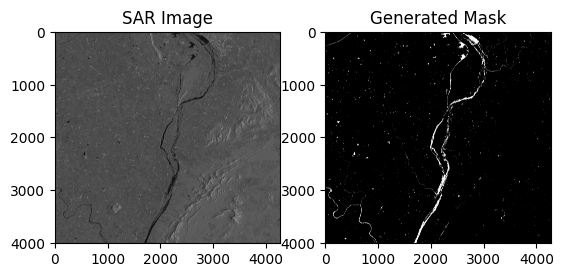

In [ ]:
import rasterio
import cv2
import numpy as np
import matplotlib.pyplot as plt
path = '/content/drive/MyDrive/SAR_hirakud_2024.tif'
with rasterio.open(path) as src:
  image = src.read(1)

# Normalize
image = (image - image.min())/(image.max() - image.min())

#Threshold
threshold = np.mean(image)*0.7

mask = (image < threshold).astype(np.uint8)

# Save mask
cv2.imwrite('/content/mask.png',mask*255)

# Visualize
plt.subplot(1,2,1)
plt.imshow(image, cmap='gray')
plt.title('SAR Image')
plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title('Generated Mask')
plt.show()


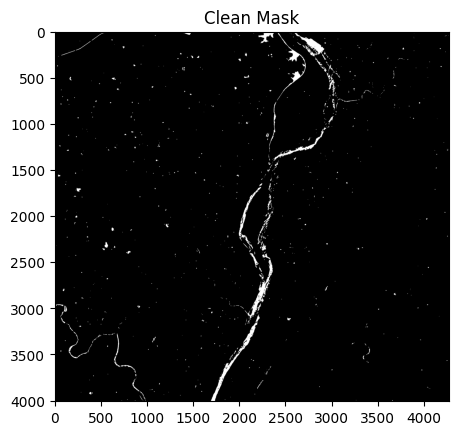

In [ ]:
mask = cv2.medianBlur(mask, 5)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))

plt.imshow(mask, cmap = 'gray')
plt.title("Clean Mask")
plt.show()

In [ ]:
cv2.imwrite('/content/drive/MyDrive/SAR_hirakud_2024/masks/img_0.png',mask*255)

True

In [ ]:
import os
image_path = '/content/drive/MyDrive/SAR_hirakud_2024.tif'
mask_dir = '/content/drive/MyDrive/masks'

os.makedirs(mask_dir, exist_ok=True)



with rasterio.open(image_path) as src:
  image = src.read(1)

image = (image - image.min())/(image.max() - image.min())


mask = (image < threshold).astype(np.uint8)
kernel = np.ones((5,5), np.unit8)

mask = cv2.medianBlur(mask, 5)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

save_path = os.path.join(mask_dir,'mask.png')
cv2.imwrite(save_path, mask*255)

print("Masks Generated")

Masks Generated


In [ ]:
image_path = '/content/drive/MyDrive/SAR_hirakud_2024.tif'
output_dir = '/content/drive/MyDrive/SAR_Dataset/images'

os.makedirs(output_dir, exist_ok=True)

with rasterio.open(image_path) as src:
  image = src.read(1)

image = (image - image.min())/(image.max() - image.min())
patch_size = 256
count = 0

h,w = image.shape

for i in range(0,h - patch_size,patch_size):
  for j in range(0,w - patch_size,patch_size):
    patch = image[i: i+patch_size, j : j+patch_size]

    if np.mean(patch) < 0.05:
      continue
    patch = (patch*255).astype(np.uint8)
    cv2.imwrite(f"{output_dir}/img_{count}.png",patch)

    count += 1

  print("Total patches:", count)

Total patches: 16
Total patches: 32
Total patches: 48
Total patches: 64
Total patches: 80
Total patches: 96
Total patches: 112
Total patches: 128
Total patches: 144
Total patches: 160
Total patches: 176
Total patches: 192
Total patches: 208
Total patches: 224
Total patches: 240


In [ ]:
image_dir = '/content/drive/MyDrive/SAR_Dataset/images'
mask_dir = '/content/drive/MyDrive/SAR_Dataset/masks'

os.makedirs(mask_dir,exist_ok= True)
threshold = 0.2

for file in os.listdir(image_dir):
  path = os.path.join(image_dir,file)
  image = cv2.imread(path, 0) / 255.0

  mask = (image < threshold).astype(np.uint8)

  mask = cv2.medianBlur(mask, 5)
  mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((3,3)))
  save_path = os.path.join(mask_dir,f"mask_{file}")
  cv2.imwrite(save_path, mask*255)

print("All masks generated")

All masks generated


In [ ]:
IMG_SIZE = 256

image_dir = '/content/drive/MyDrive/SAR_Dataset/images'
mask_dir = '/content/drive/MyDrive/SAR_Dataset/masks'
images = []
masks = []

for file in os.listdir(image_dir):
  img = cv2.imread(os.path.join(image_dir, file),0)
  img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
  img = img/255.0

  mask_path = os.path.join(mask_dir, 'mask_' + file)
  mask  = cv2.imread(mask_path,0)

  if mask is None:
    print("Mask not found:" , file)
    continue

  images.append(img)
  masks.append(mask)

X = np.array(images).reshape(-1, IMG_SIZE, IMG_SIZE,1)
y = np.array(masks).reshape(-1, IMG_SIZE, IMG_SIZE,1)

print("Dataset: ",X.shape,y.shape)

Dataset:  (240, 256, 256, 1) (240, 256, 256, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X,y,test_size = 0.3,random_state = 42)

In [ ]:
print("Shape of X train : ",X_train.shape)
print("Shape of X test : ",X_val.shape)
print("Shape of y train : ",y_train.shape)
print("Shape of y test : ",y_val.shape)

Shape of X train :  (168, 256, 256, 1)
Shape of X test :  (72, 256, 256, 1)
Shape of y train :  (168, 256, 256, 1)
Shape of y test :  (72, 256, 256, 1)


In [ ]:
from urllib.request import url2pathname
import tensorflow as tf
from tensorflow.keras import layers

def unet():
  inputs = tf.keras.Input((256, 256,1))

  c1 = layers.Conv2D(16,3,activation='relu', padding = 'same')(inputs)
  p1 = layers.MaxPooling2D()(c1)

  c2 = layers.Conv2D(32,3,activation = 'relu',padding = 'same')(p1)
  p2 = layers.MaxPooling2D()(c2)

  b = layers.Conv2D(64,3,activation = 'relu',padding = 'same')(p2)

  u1 = layers.UpSampling2D()(b)
  c3 = layers.Conv2D(32,3,activation = 'relu',padding = 'same')(u1)

  u2 = layers.UpSampling2D()(c3)
  c4 = layers.Conv2D(16,3, activation = 'relu',padding = 'same')(u2)

  outputs = layers.Conv2D(1,1,activation = 'sigmoid')(c4)

  return tf.keras.Model(inputs = inputs, outputs = outputs)

model = unet()
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 256, 256, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 256, 256, 1)    │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,401 (181.25 KB)

 Trainable params: 46,401 (181.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def dice_loss(y_true, y_pred):
  smooth = 1e-7 # Added a small epsilon to prevent division by zero
  # Cast y_true to float32 to ensure type compatibility with y_pred
  y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
  y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
  intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
  # Corrected to use y_true_f instead of the global 'y' variable
  return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

model.compile(optimizer='adam',loss = dice_loss)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range = 20,
    horizontal_flip = True,
    vertical_flip = True,
    zoom_range = 0.2
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 15,
    batch_size = 4
)

Epoch 1/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.0236 - loss: -0.2076 - val_accuracy: 0.0000e+00 - val_loss: -0.4242
Epoch 2/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.0000e+00 - loss: -0.2937 - val_accuracy: 0.0000e+00 - val_loss: -0.4242
Epoch 3/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.0000e+00 - loss: -0.2886 - val_accuracy: 0.0000e+00 - val_loss: -0.4242
Epoch 4/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.0000e+00 - loss: -0.2867 - val_accuracy: 0.0000e+00 - val_loss: -0.4242
Epoch 5/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.0000e+00 - loss: -0.3547 - val_accuracy: 0.0000e+00 - val_loss: -0.4242
Epoch 6/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.0000e+00 - loss: -0.2506 - val_accuracy: 0.0000e+00 - val_loss: -0.4242
Epoch 7/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 83s 1s/step - accuracy: 0.0000e+00 - loss: -0.3525 - val_accuracy: 0.0000e+00 - val_loss: -0.4242
Epoch 8/15
42/42 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - 

In [ ]:
def combined_loss(y_true, y_pred):
  bce = tf.keras.losses.BinaryCrossentropy(y_true, y_pred)
  smooth = 1
  intersection = tf.reduce_sum(y_true * y_pred)
  dice = (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)
  return bce +(1-dice)

  def dice_loss(y_true, y_pred):
  smooth = 1e-7 # Added a small epsilon to prevent division by zero
  # Cast y_true to float32 to ensure type compatibility with y_pred
  y_true_f = tf.keras.backend.flatten(tf.cast(y_true, tf.float32))
  y_pred_f = tf.keras.backend.flatten(tf.cast(y_pred, tf.float32))
  intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
  # Corrected to use y_true_f instead of the global 'y' variable
  return 1 - (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

model.compile(optimizer='adam',loss = dice_loss)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step


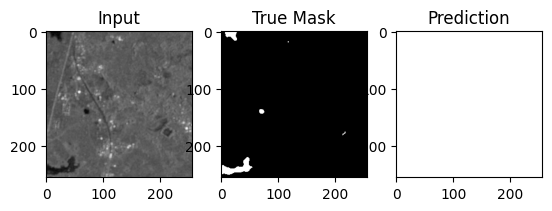

In [ ]:
pred = model.predict(X_val[0:1])[0]

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(X_val[0].squeeze(),cmap = 'gray')

plt.subplot(1,3,2)
plt.title("True Mask")
plt.imshow(y_val[0].squeeze(),cmap = 'gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred[0].squeeze(),cmap = 'gray')

plt.show()

In [ ]:
image = np.log1p(image)
image = (image - image.min())/image.std()

In [ ]:
tif_path = '/content/drive/MyDrive/SAR_hirakud_2024.tif'
image_dir = '/content/drive/MyDrive/images'

os.makedirs(image_dir,exist_ok=True)

with rasterio.open(tif_path) as src:
  image = src.read(1)

image = np.log1p(image)
image = (image - np.min(image)) / (np.max(image) - np.min(image))

patch_size = 256
count = 0

h,w = image.shape

for i in range(0,h - patch_size,patch_size):
  for j in range(0,w - patch_size,patch_size):

    patch = image[i:i+patch_size,j:j+patch_size]

    if np.mean(patch) < 0.05:
      continue

    patch = (patch*255).astype(np.uint8)
    cv2.imwrite(f"{image_dir}/img_{count}.png",patch)

    count += 1

  print("Total patches:",count)
  mask_dir = '/content/drive/MyDrive/images'
os.makedirs(mask_dir,exist_ok=True)

for file in os.listdir(image_dir):

  path = os.path.join(image_dir, file)
  image = cv2.imread(path , 0)
# Adaptive Threshold
  water_th = np.percentile(image, 30)
  sediment_th = np.percentile(image, 60)

  mask = np.zeros_like(image, dtype = np.uint8)
  kernel = np.ones((5,5), np.unit8)

  mask = cv2.medianBlur(mask, 5)
  mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
  mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

  mask[image < water_th] = 1

  mask[(image >= water_th) & (image < sediment_th)] = 2

  cv2.imwrite(os.path.join(mask_dir, file), mask)

print("Mask created!")
IMG_SIZE = 256

images = []
masks = []

for file in os.listdir(image_dir):
  img = cv2.imread(os.path.join(image_dir, file),0)
  img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))/255.0

  mask = cv2.imread(os.path.join(mask_dir, file),0)
  mask = cv2.resize(mask,(IMG_SIZE,IMG_SIZE))

  images.append(img)
  masks.append(mask)

X = np.array(images).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(masks)

y = tf.keras.utils.to_categorical(y, 3)

print("Dataset: ", X.shape,y.shape)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range = 20,
    horizontal_flip = True,
    vertical_flip = True,
    zoom_range = 0.2
)
def dice_loss(y_true,y_pred):
  smooth = 1.
  y_true_f = tf.reshape(y_true,[-1])
  y_pred_f = tf.reshape(y_pred,[-1])

  intersection = tf.reduce_sum(y_true_f * y_pred_f)
  return 1 - (2. * intersection + smooth) /(tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def combined_loss(y_true, y_pred):
  return tf.keras.losses.categorical_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)

from urllib.request import url2pathname
import tensorflow as tf
from tensorflow.keras import layers

def unet():
  inputs = tf.keras.Input((256, 256,1))

  c1 = layers.Conv2D(32,3,activation='relu', padding = 'same')(inputs)
  p1 = layers.MaxPooling2D()(c1)

  c2 = layers.Conv2D(64,3,activation = 'relu',padding = 'same')(p1)
  p2 = layers.MaxPooling2D()(c2)

  b = layers.Conv2D(128,3,activation = 'relu',padding = 'same')(p2)

  u1 = layers.UpSampling2D()(b)
  c3 = layers.Conv2D(64,3,activation = 'relu',padding = 'same')(u1)

  u2 = layers.UpSampling2D()(c3)
  c4 = layers.Conv2D(32,3, activation = 'relu',padding = 'same')(u2)

  outputs = layers.Conv2D(3,1,activation = 'softmax')(c4)

  return tf.keras.Model(inputs = inputs, outputs = outputs)

model = unet()
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(patience = 5,restore_best_weights = True)

history = model.fit(
    X_train,y_train,
    validation_data = (X_val, y_val),
    epochs = 25,
    batch_size = 8,
    callbacks = [early_stop]
)

pred = model.predict(X_val)

pred_class = np.argmax(pred,axis = -1)
true_class = np.argmax(y_val,axis = -1)

num_classes = 3

ious = []

for cls in range(num_classes):
  intersection = np.logical_and(pred_class == cls,true_class == cls)
  union = np.logical_or(pred_class == cls, true_class == cls)

  iou = np.sum(intersection)/(np.sum(union) + 1e-7)
  ious.append(iou)

class_names = ['Land','Water','Sediment']
for i in range(num_classes):
  print(f"{class_names[i]} IoU: ",round(np.mean(ious),4))


pred = model.predict(X_val[0:1])[0]
pred_class = np.argmax(pred, axis = -1)

plt.figure(figsize = (10,3))

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(X_val[0].squeeze(),cmap = 'gray')

plt.subplot(1,3,2)
plt.title("True")
plt.imshow(np.argmax(y_val[0], axis= -1))

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred_class)

plt.show()


sediment_pixels = np.sum(pred_class == 2)
total_pixels = pred_class.size

sediment_percentage = (sediment_pixels / total_pixels)*100
print("Sediment Area %:",sediment_percentage)